Before filtering:
               time         energy
count  5.400910e+05  540091.000000
mean   7.854256e+08     657.005789
std    2.455940e+06    2017.113152
min    7.804545e+08     100.000038
25%    7.830112e+08     186.619041
50%    7.861667e+08     320.299591
75%    7.874730e+08     634.793060
max    7.901001e+08  278458.968750


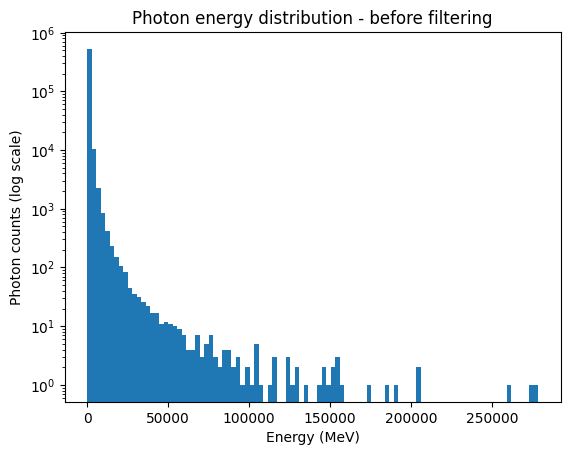

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

hdul = fits.open("../data/raw/vela_photons.fits")
events = hdul[1].data

df = pd.DataFrame({
    "time": events["TIME"].astype(float),
    "energy": events["ENERGY"].astype(float)
})

print("Before filtering:")
print(df.describe())

plt.figure()
plt.hist(df["energy"], bins=100, log=True)
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts (log scale)")
plt.title("Photon energy distribution - before filtering")
plt.show()


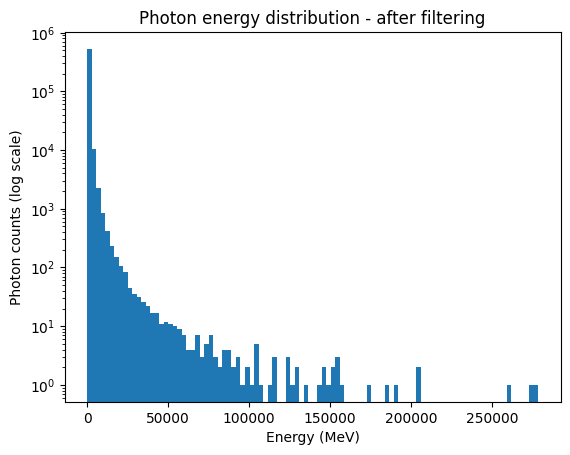

After energy filtering:
               time         energy
count  5.400910e+05  540091.000000
mean   7.854256e+08     657.005789
std    2.455940e+06    2017.113152
min    7.804545e+08     100.000038
25%    7.830112e+08     186.619041
50%    7.861667e+08     320.299591
75%    7.874730e+08     634.793060
max    7.901001e+08  278458.968750
Events reduced from 540091 to 540091 (100.00% retained)


In [2]:
energy_min = 100
df_filtered = df[df["energy"] >= energy_min]

plt.figure()
plt.hist(df_filtered["energy"], bins=100, log=True)
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts (log scale)")
plt.title("Photon energy distribution - after filtering")
plt.show()

print("After energy filtering:")
print(df_filtered.describe())
print(f"Events reduced from {len(df)} to {len(df_filtered)} ({100*len(df_filtered)/len(df):.2f}% retained)")


In [3]:
time_min = df_filtered["time"].min()
time_max = df_filtered["time"].max()
time_cut = time_min + (time_max - time_min)/2

df_filtered = df_filtered[df_filtered["time"] <= time_cut]

print(f"After time filtering: {len(df_filtered)} events retained")


After time filtering: 249148 events retained


We filter photon events to reduce background noise.
Energy cut (E > 100 MeV) removes low-energy background photons.
Optional time filtering allows us to test analysis on subsets of data.
This preprocessing ensures more robust detection of pulsar periodicity in subsequent steps.